In [37]:
#import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
#đọc dữ liệu
train_df = pd.read_csv("../dataset/titanic_train.csv",index_col="PassengerId")
test_df = pd.read_csv("../dataset/titanic_test.csv",index_col="PassengerId")

###  Tổng quan DATA

In [39]:

# Cột SibSp là cột số lượng người thân hoặc vợ chồng với hành khách
# Cột Parch là cột số lượng ba mẹ hoặc con với hành khách
train_df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [40]:
test_df.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked'],
      dtype='str')

In [41]:
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
test_df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [43]:
train_df.info()
# Các cột thiếu dữ liệu : Cabin,Age,Embarked

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [44]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    str    
 2   Sex       418 non-null    str    
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    str    
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     str    
 9   Embarked  418 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 32.8 KB



### Chuyển các cột thành category 

In [45]:
features= ["Pclass","Sex","Embarked","SibSp","Parch"]
def convert_cat(df,features):
  for feature in features:
    df[feature]= df[feature].astype("category")

train_df["Survived"]=train_df["Survived"].astype("category")
convert_cat(train_df,features)
convert_cat(test_df,features)

In [46]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    category
 1   Pclass    891 non-null    category
 2   Name      891 non-null    str     
 3   Sex       891 non-null    category
 4   Age       714 non-null    float64 
 5   SibSp     891 non-null    category
 6   Parch     891 non-null    category
 7   Ticket    891 non-null    str     
 8   Fare      891 non-null    float64 
 9   Cabin     204 non-null    str     
 10  Embarked  889 non-null    category
dtypes: category(6), float64(2), str(3)
memory usage: 40.6 KB


### Phân bổ các cột numerical


In [47]:
train_df.describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


### Phân bổ các cột category

In [48]:
train_df.describe(include=["category"])


,Survived,Pclass,Sex,SibSp,Parch,Embarked
count,891,891,891,891,891,889
unique,2,3,2,7,7,3
top,0,3,male,0,0,S
freq,549,491,577,608,678,644


### Phân tích biến mục tiêu  

In [49]:
# Số người sống sót
train_df["Survived"].value_counts().to_frame()

,count
Survived,
0,549
1,342


In [50]:
# Tỉ lệ sống sót
train_df["Survived"].value_counts(normalize=True).to_frame()

,proportion
Survived,
0,0.616162
1,0.383838



Biến mục tiêu `Survived` biểu thị việc hành khách có sống sót sau thảm họa Titanic hay không:

- `0`: Không sống sót
- `1`: Sống sót

Từ dữ liệu thống kê:

- Có **549 hành khách không sống sót**, chiếm khoảng **61.6%** tổng số hành khách.
- Có **342 hành khách sống sót**, chiếm khoảng **38.4%**.

Điều này cho thấy **đa số hành khách trên tàu Titanic đã không sống sót** trong thảm họa.


### Trực quan hóa qua biểu đồ (Visualization) + Phân bố dữ liệu numerical(Distribution plots)

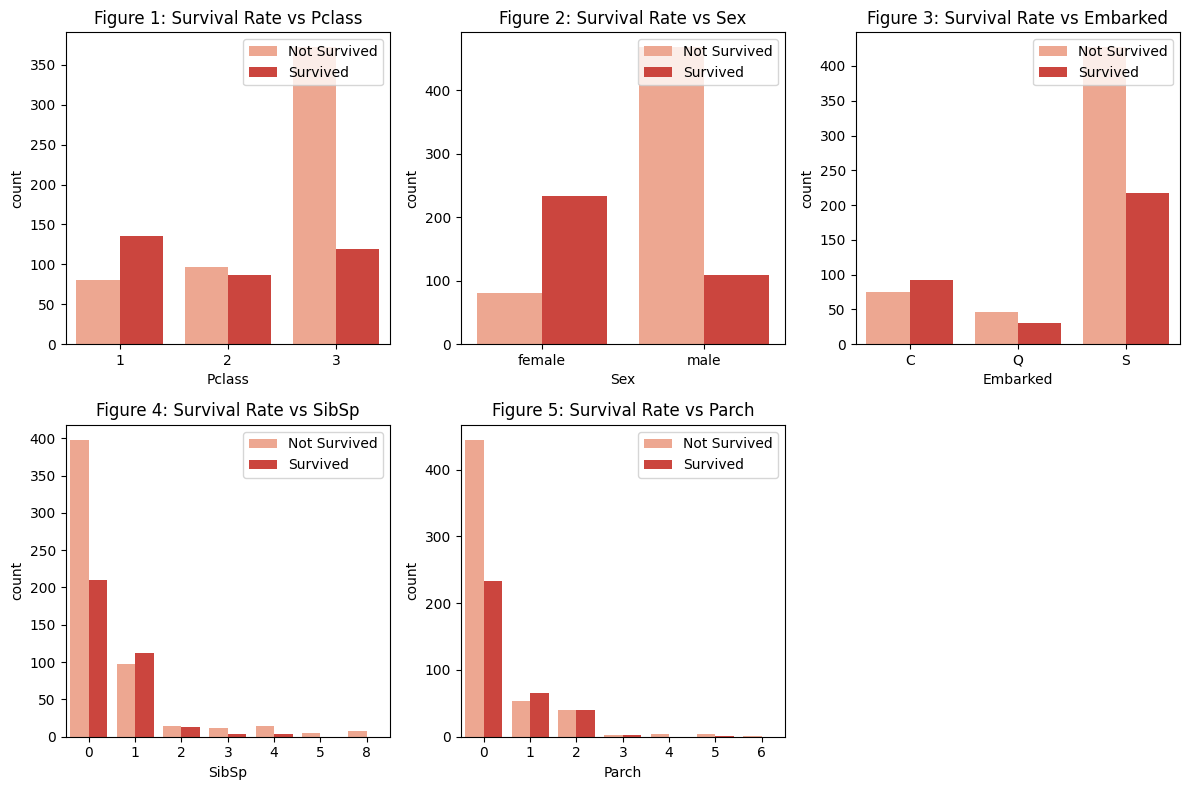

In [51]:

# Với dữ liệu các cột category
cols= ["Pclass","Sex","Embarked","SibSp","Parch"]
n_rows = 2
n_cols= 3
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4  ))
for r in range(0, n_rows):
  for c in range(0,n_cols):
    i = r*n_cols + c
    if i < len(cols):
      ax_i = ax[r,c]
      #Vẽ biểu đồ
      sns.countplot(data=train_df, x=cols[i],hue="Survived", palette="Reds", ax=ax_i)
      #Set tiêu đề cho mỗi subplot
      ax_i.set_title(f"Figure {i+1}: Survival Rate vs {cols[i]}")
      #Set chú thích cho mỗi subplot ( tiêu đề, vị trí, các nhãn)
      ax_i.legend(title ="", loc="upper right", labels=["Not Survived","Survived"])
ax.flat[-1].set_visible(False) # Ẩn subplot cuối
plt.tight_layout()


<Axes: xlabel='Age', ylabel='Count'>

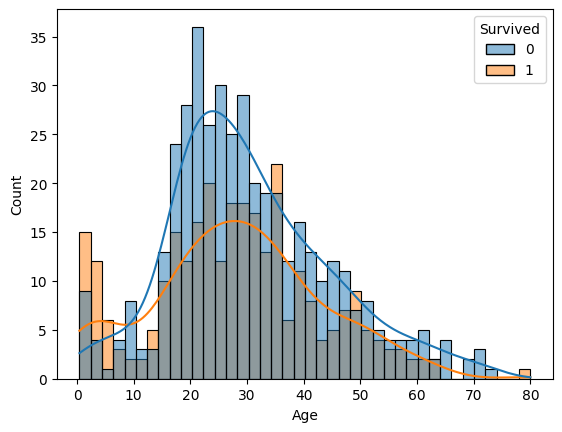

In [52]:
#Distribution plots
# Với dữ liệu các cột numerical
sns.histplot(data=train_df, x="Age", bins = 40, kde=True,hue="Survived")

<Axes: xlabel='Fare', ylabel='Count'>

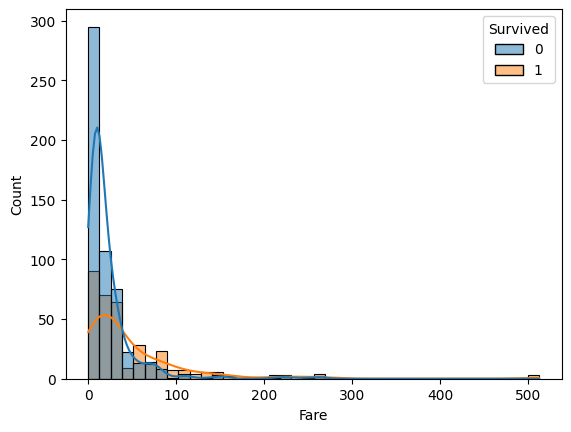

In [53]:
sns.histplot(data=train_df, x="Fare", bins = 40, kde=True,hue="Survived")

Text(0.5, 0, 'Fare Category')

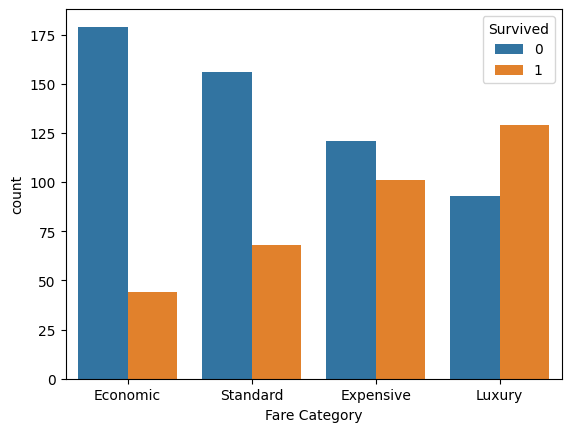

In [54]:
#Biểu đồ theo hạng mức giá vé
#Dán nhãn từng khoảng
fare_category =["Economic","Standard","Expensive", "Luxury"]
#Dán nhãn cho từng khoảng
quartile_data=pd.qcut(train_df["Fare"],4,labels=fare_category)
#Vẽ biểu đồ cho các khoảng
sns.countplot(x=quartile_data, hue=train_df["Survived"])
plt.xlabel("Fare Category")

### Phân tích Correlation


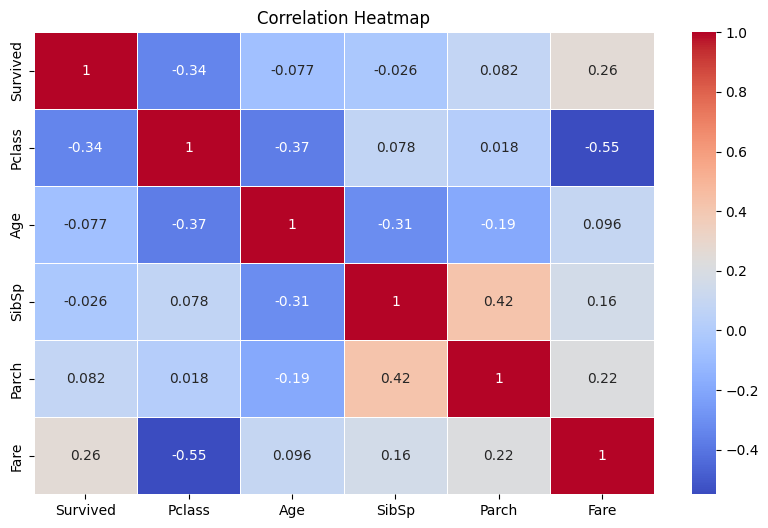

In [55]:
# copy dataframe
corr_df = train_df.copy()

# chuyển category -> numeric
for col in corr_df.select_dtypes(['category']).columns:
    corr_df[col] = corr_df[col].cat.codes

corr_df = corr_df.drop(columns=["Name","Ticket","Cabin","Embarked","Sex",])

corr_matrix = corr_df.corr()


plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show() 




#### Nhận xét phân tích tổng thể:

Từ heatmap có thể rút ra một số kết luận quan trọng:

- Pclass có mối liên hệ rõ ràng với Survived, cho thấy tầng lớp xã hội ảnh hưởng đến khả năng sống sót:
    - Tương quan âm mức trung bình : -0.34.
    - Giá trị âm nghĩa là khi Pclass tăng (tức là hạng thấp hơn), khả năng sống sót giảm.
- Fare cũng có tương quan dương với Survived, phản ánh mối quan hệ giữa giá vé và vị trí trên tàu:
    - Tương quan dương mức trung bình : 0.26.
    - Giá trị dương cho thấy hành khách trả giá vé cao hơn thường có khả năng sống sót cao hơn.
- Age, SibSp, và Parch có tương quan yếu (gần = 0) với biến mục tiêu, nên mức độ ảnh hưởng trực tiếp không lớn.
- Pclass và Fare có tương quan mạnh với nhau, vì giá vé phụ thuộc vào hạng vé:
    - Tương quan âm mức mạnh : -0.55.
    - Giá trị âm nghĩa là khi Pclass tăng (tức là hạng thấp hơn) thì Fare giảm.
- SibSp và Parch có tương quan trung bình, phản ánh cấu trúc gia đình của hành khách:
    - Tương quan dương mức trung bình : 0,42.
    - Cho thấy gia đình lớn thường có cả anh chị em/vợ chồng và cha mẹ/con cái đi cùng.
- Age và Pclass có tương quan trung bình, phản ánh cấu trúc gia đình của hành khách:
    - Tương quan âm mức trung bình : -0,37.
    - Cho thấy hành khách ở hạng cao có xu hướng lớn tuổi hơn

### Outlier Detection :Box Plot + IQR Analysis

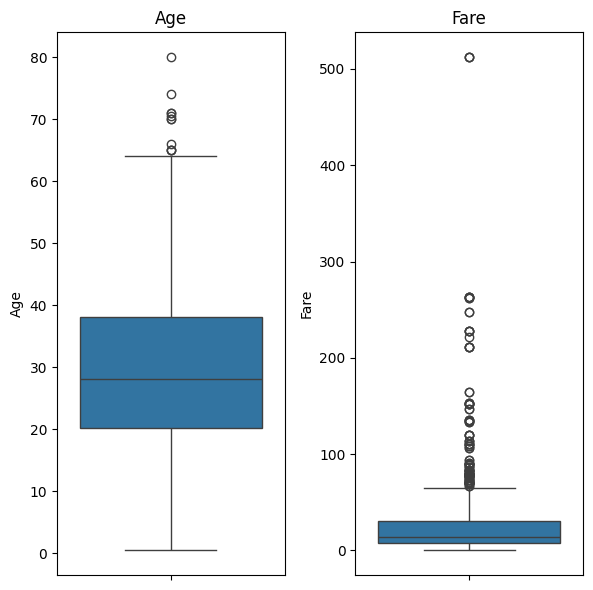

In [56]:

#Liệt kê các cột numerical
num_cols = ["Age","Fare"]
plt.figure(figsize=(12,6))

for i, col in enumerate(num_cols):
    plt.subplot(1,4,i+1)
    sns.boxplot(y=train_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [57]:

for col in num_cols:
    
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    
    print(f"{col}")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))
    print("-"*40)

Age
Lower bound: -6.6875
Upper bound: 64.8125
Number of outliers: 11
----------------------------------------
Fare
Lower bound: -26.724
Upper bound: 65.6344
Number of outliers: 116
----------------------------------------


#### Phân tích:
-   Age có rất ít chỉ 11 outliers, dữ liệu khá ổn định:
    - Ngưỡng dưới là -6.68, nhưng tuổi không thể âm nên thực tế không có outlier ở phía dưới.
    - Ngưỡng trên là 64.81, do đó các hành khách có tuổi lớn hơn khoảng 65 tuổi được xem là outliers.
-   Fare có nhiều outliers, do sự khác biệt lớn giữa các hạng vé:
    -  Ngưỡng dưới là -26.72, nhưng giá vé không thể âm nên không có outliers phía dưới.
    -  Ngưỡng trên là 65.63, vì vậy các vé có giá lớn hơn 65.63 được xem là outliers
-   Những outliers của Fare phản ánh đặc điểm thực tế của dữ liệu, nên không nhất thiết phải loại bỏ.

### Preprocessing + Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


# Numerical features
num_features = ['Age', 'Fare']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical features
cat_features = ['Embarked',"Sex",'Pclass']

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])


model_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression())
])


### Feature Engineering

1.Phân tích theo nhóm Family

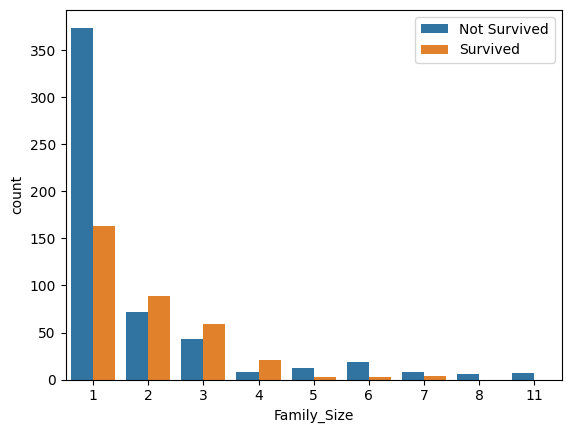

In [60]:
train_df["Family_Size"] = train_df["SibSp"].astype("int") + train_df["Parch"].astype("int") + 1
test_df["Family_Size"] = test_df["SibSp"].astype("int") + test_df["Parch"].astype("int") + 1
sns.countplot(data=train_df, x="Family_Size", hue="Survived")
plt.legend(title="",labels=['Not Survived','Survived'])


<Axes: xlabel='Family_Cat', ylabel='count'>

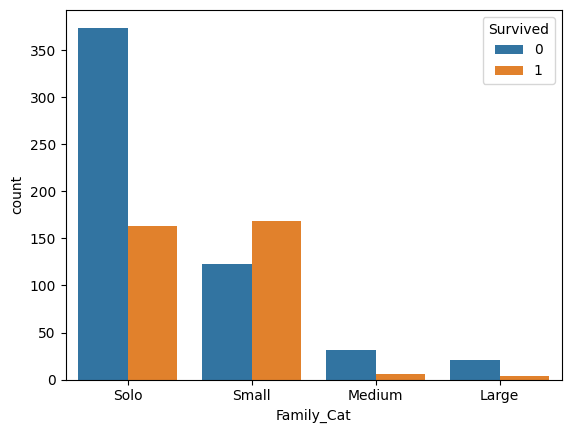

In [61]:
train_df["Family_Cat"]= pd.cut(train_df["Family_Size"], bins=[0,1,4,6,20], labels=["Solo","Small","Medium","Large"])
test_df["Family_Cat"]= pd.cut(test_df["Family_Size"], bins=[0,1,4,6,20], labels=["Solo","Small","Medium","Large"])
sns.countplot(data=train_df, x=train_df["Family_Cat"],hue="Survived")

NHẬN XÉT:


> Phần lớn hành khách có Family_Size = 1 (đi một mình), và trong nhóm này số người không sống sót nhiều hơn đáng kể so với số người sống sót

>  Khi Family_Size tăng lên khoảng 2–4, số người sống sót bắt đầu cao hơn hoặc gần tương đương với số người không sống sót, cho thấy những hành khách đi cùng gia đình nhỏ có xu hướng có cơ hội sống sót tốt hơn, có thể do hỗ trợ lẫn nhau trong quá trình sơ tán


> Tuy nhiên, khi Family_Size quá lớn (>= 5), số người không sống sót tăng lên rõ rệt và số người sống sót rất ít. Điều này cho thấy gia đình quá đông có thể gặp khó khăn trong việc di chuyển và lên thuyền cứu sinh kịp thời

2.Phân tích theo nhóm Họ (Name)

In [62]:
import re
def extract_title(name):
    match = re.search(r',([\w\s]+)\.', name)
    if match:
        return match.group(1).strip()
    return None

train_df["Title"] = train_df["Name"].apply(lambda x: extract_title(x))
train_df["Title"].value_counts()


Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [63]:
def group_titles(title):
    if title in ["Mr","Miss","Mrs","Master"]:
        return title
    elif title =="Ms":
        return "Miss"
    else:
        return "Other"

train_df["Title"] = train_df["Title"].apply(lambda x: group_titles(x))
test_df["Title"] = test_df["Name"].apply(lambda x: extract_title(x))


<Axes: xlabel='Title', ylabel='count'>

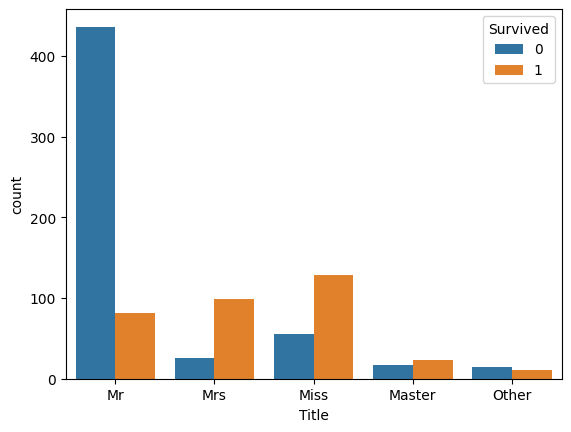

In [64]:
sns.countplot(data=train_df, x="Title", hue="Survived")

NHẬN XÉT:

> Phân bố theo Title cho thấy nhóm "Mr" (nam giới trưởng thành) chiếm số lượng lớn nhất, tuy nhiên tỷ lệ sống sót của nhóm này thấp hơn đáng kể so với số người không sống sót.

> Ngược lại, các nhóm "Mrs"(phụ nữ) và "Miss" (phụ nữ trẻ/bé gái) có tỷ lệ sống sót cao hơn rõ rệt, cho thấy phụ nữ có nhiều cơ hội được cứu hơn trong quá trình sơ tán.

> Nhóm "Master" ( bé trai) cũng có tỷ lệ sống sót khá cao dù số lượng không nhiều, phản ánh quy tắc ưu tiên cứu phụ nữ và trẻ em.

> Các nhóm còn lại ("Other") có số lượng ít nên không thể rút ra kết luận rõ ràng, tuy nhiên nhìn chung không có tỷ lệ sống sót nổi bật.